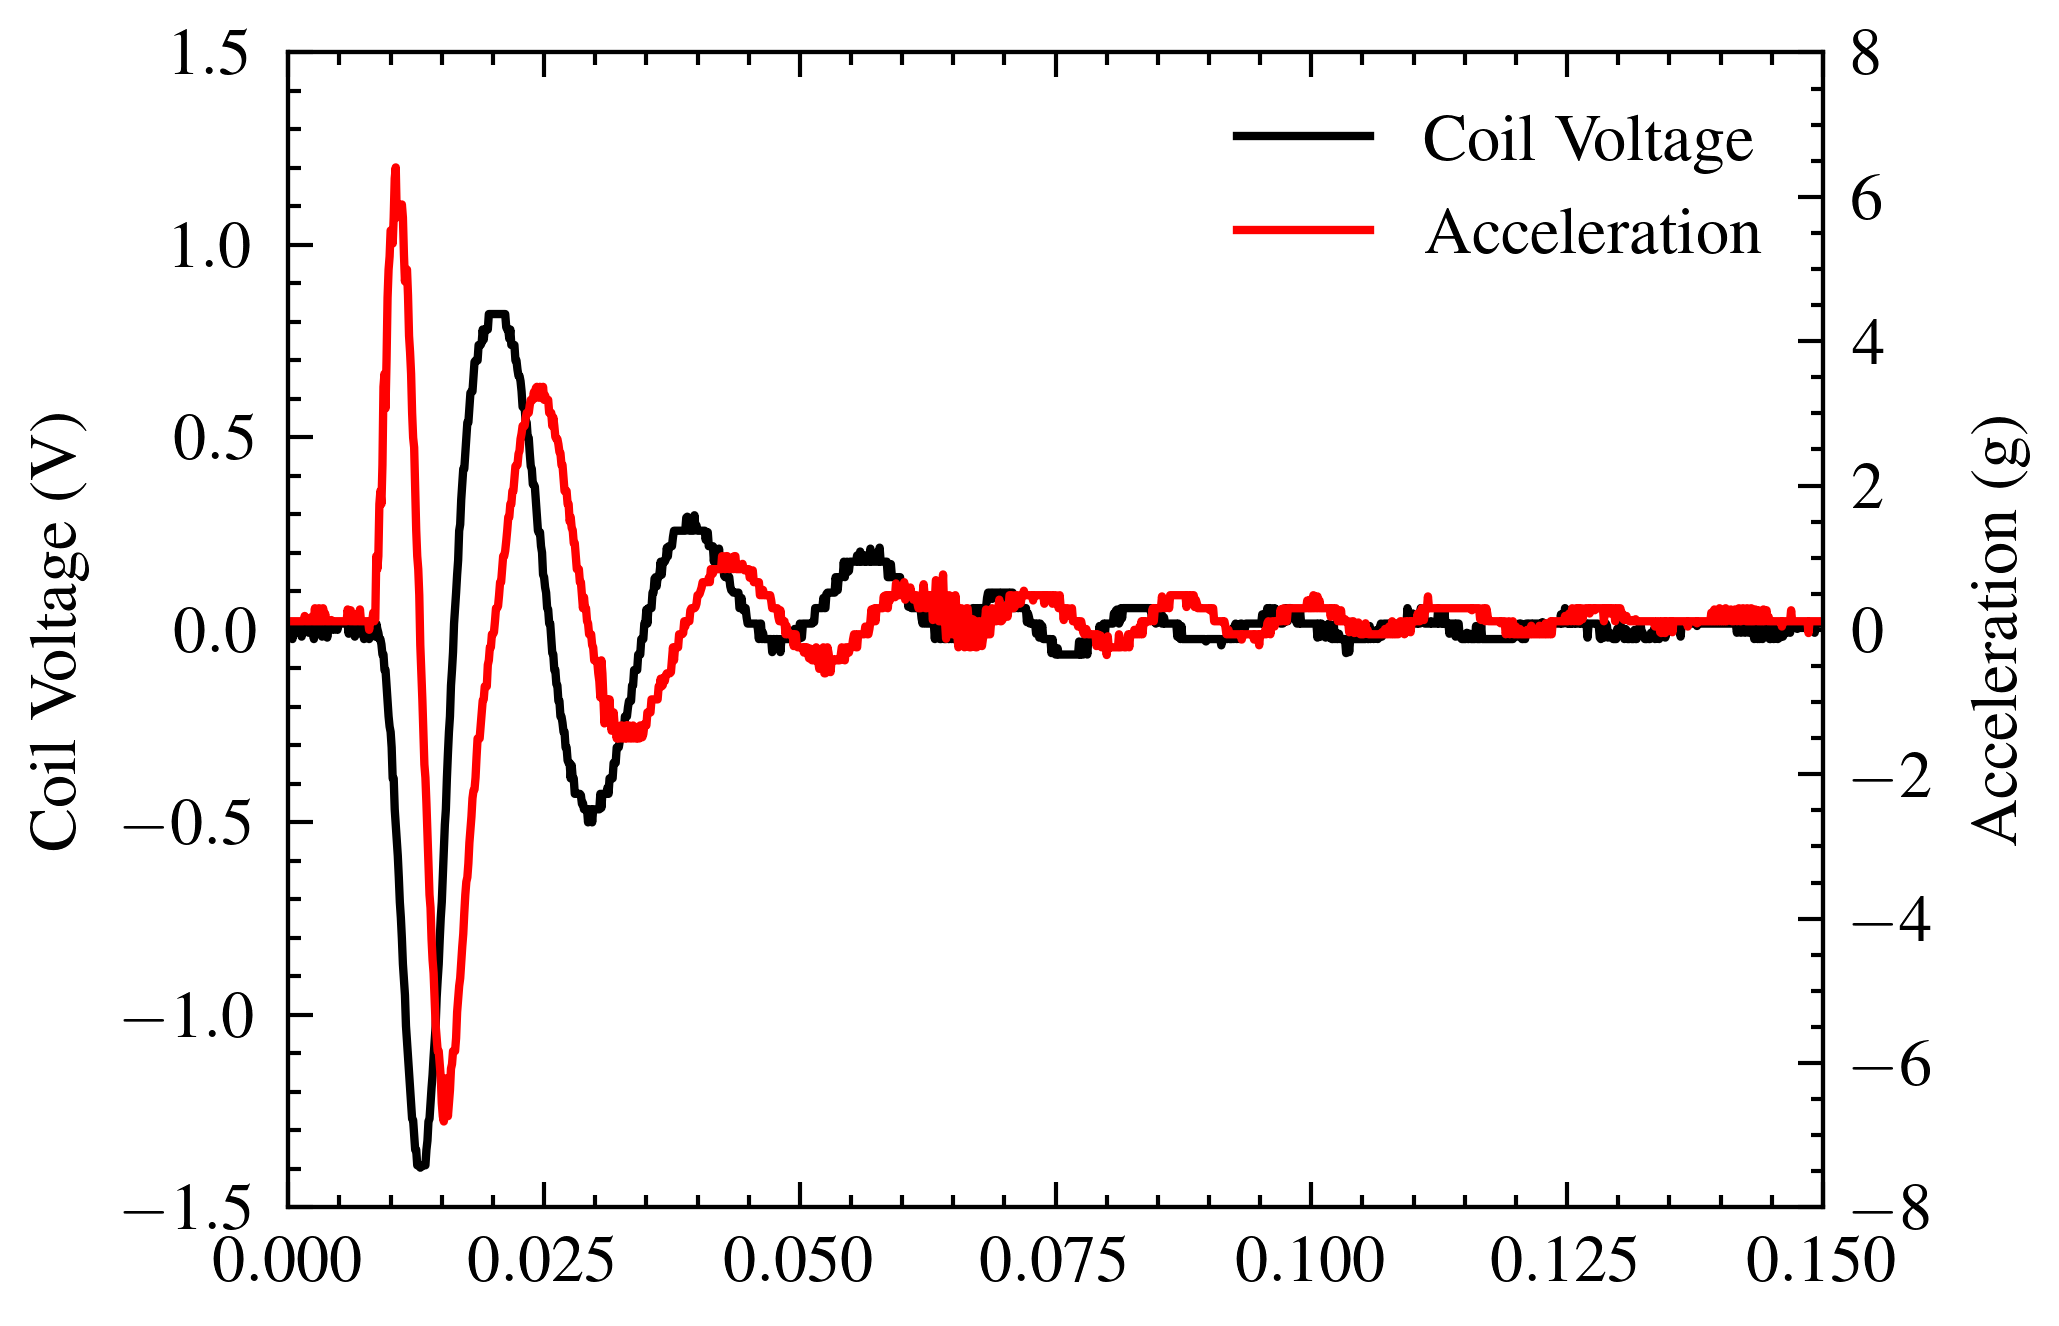

In [6]:
import pandas as pd
import matplotlib.pyplot as plt
import scienceplots

# Load CSV file
file_path = "input_data/voltage_accel_tap.csv"

# Skip the second row containing units
df = pd.read_csv(file_path, skiprows=[1])

# Rename columns for clarity
df.columns = ["time", "voltage_1", "voltage_2"]

# Convert columns to numeric values
df = df.apply(pd.to_numeric, errors='coerce')

# Plot both voltage signals against time
fig, ax = plt.subplots()

t_offset = 0.01

lns1 = ax.plot(df["time"]+t_offset, -df["voltage_1"], label="Coil Voltage")
ax.set_ylabel("Coil Voltage (V)")
ax.set_ylim([-1.5,1.5])
ax.set_xlim(0, 0.15);

ax2 = ax.twinx()
lns2 = ax2.plot(df["time"]+t_offset, -df["voltage_2"] / (0.04 * 5.57), label="Acceleration",color='red')
ax2.set_ylabel("Acceleration (g)")
ax2.set_ylim([-8, 8])

lns = lns1+lns2
labs = [l.get_label() for l in lns]
ax.legend(lns, labs)

# Labels and formatting
plt.xlabel("Time (s)")
#plt.ylabel("Voltage (V)")
#plt.title("Voltage Signals vs Time")

#plt.grid(True)

plt.style.use(['science', 'ieee'])

#plt.tight_layout()
plt.savefig('outputs/voltage_tap.eps', format='eps')
plt.show()